# Tutorial 02: Observer-Frame Data Input

## Overview

Tutorial 01 loaded rest-frame luminosities. Most catalogues do not give you those —
they give you observer-frame fluxes or AB magnitudes. This tutorial shows how to hand
those to FitTeD directly and let it do the cosmology.

## Learning Objectives

By the end of this tutorial, you will:

- Know how to input observer-frame fluxes, AB magnitudes and X-ray fluxes
- Understand exactly which conversions are applied
- Know how to mix input formats in one `Data_Set`
- Know the one place the conversion is approximate, and why

## Prerequisites

- **Tutorial 01: Data Loading Basics**

## The conversions

Give FitTeD a redshift alongside observer-frame data and it applies:

| Quantity | Conversion |
|----------|------------|
| Time | `t_rest = t_obs / (1 + z)` |
| Frequency (monochromatic) | `ν_rest = ν_obs × (1 + z)` |
| Energy band (integrated) | `E_rest = E_obs × (1 + z)` |
| Flux → luminosity (monochromatic) | `νL_ν = ν_obs × 4π d_L² × f_ν(ν_obs)` |
| Flux → luminosity (integrated) | `L = 4π d_L² × F` |

The luminosity distance `d_L` is computed from the redshift with
`astropy.cosmology.Planck18`. If you have your own distance — a redshift-independent
one for a nearby object, say — pass rest-frame data instead and scale it yourself.

Two things worth internalising. The νL_ν form is deliberate: because νL_ν = ν_obs ×
4π d_L² × f_ν(ν_obs), the (1+z) factors from time dilation and frequency shift cancel,
so this particular combination needs no K-correction. And the band-integrated case is
the one that *does*: see the warning below.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# If FitTeD was installed with `pip install -e .` this block is unnecessary.
# It is here so the notebooks also work from a bare checkout.
package_dir = Path().resolve().parent
if str(package_dir) not in sys.path:
    sys.path.append(str(package_dir))   # append, so an installed copy wins

import fitted
fitted.format_plots()

print("FitTeD", fitted.__version__)


  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  Yes

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward.j.r.nathan@gmail.com




FitTeD 2.0.0


## Observer-frame fluxes

```python
Data_Set(
    args_UV_flux=[[times, fluxes, errors, freq]],   # days, erg/s/cm²/Hz, ..., Hz
    bands_UV_flux=['g.flux'],                       # REQUIRED
    redshift=0.1,                                   # REQUIRED
    global_systematic=0.1,
)
```

All four of `times`, `fluxes`, `errors`, `freq` are in the **observer** frame.

### What a realistic flux looks like

Before the example, a scale. Optical fluxes in these units are *small* numbers, and it is
easy to be out by orders of magnitude without noticing — the conversion will happily
return whatever you asked for.

The AB magnitude system is the quickest anchor:

$$f_\nu = 10^{-0.4\,(m_{\rm AB} + 48.6)} \quad \mathrm{erg\,s^{-1}\,cm^{-2}\,Hz^{-1}}$$

| AB magnitude | f_ν (erg/s/cm²/Hz) |
|---|---|
| 18 | 2.3 × 10⁻²⁷ |
| 20 | 3.6 × 10⁻²⁸ |
| 22 | 5.8 × 10⁻²⁹ |

So a TDE at z = 0.1 peaking near 19th–20th magnitude has `f_ν` of order 10⁻²⁷ to 10⁻²⁸,
which comes out as νL_ν of a few times 10⁴² erg/s. If your converted luminosity lands far
outside 10⁴¹–10⁴⁵, check your input units before anything else: 10⁴⁵ erg/s is roughly
Eddington for a 10⁷ M☉ black hole, and nothing in this business is a thousand times
Eddington.

In [2]:
z = 0.1

times_obs = np.array([0.0, 10.0, 20.0, 30.0, 40.0])       # days, observer frame
# ~19.5 mag fading to ~20.7; see the table above.
fluxes_g = np.array([6.0e-28, 5.0e-28, 4.0e-28, 3.0e-28, 2.0e-28])  # erg/s/cm^2/Hz
errors_g = fluxes_g * 0.1
frequency_g = 6.0e14                                      # Hz, observer frame

data_flux = fitted.data.Data_Set(
    args_UV_flux=[[times_obs, fluxes_g, errors_g, frequency_g]],
    bands_UV_flux=['g.flux'],
    redshift=z,
)

t_rest, L_rest, e_rest = data_flux.args_band['g.flux']

print("redshift               %.4f" % data_flux.redshift)
print("luminosity distance    %.1f Mpc" % data_flux.d_Mpc)
print("frequency  obs -> rest %.3e -> %.3e Hz"
      % (frequency_g, data_flux.bands_freq['g.flux']))
print("first time obs -> rest %.2f -> %.2f days" % (times_obs[0], t_rest[0]))
print("last time  obs -> rest %.2f -> %.2f days" % (times_obs[-1], t_rest[-1]))
print("first flux -> nu L_nu  %.2e -> %.3e erg/s" % (fluxes_g[0], L_rest[0]))

No default colour for band g.flux, colour for this band currently default matplotlib colour 0.
redshift               0.1000
luminosity distance    475.8 Mpc
frequency  obs -> rest 6.000e+14 -> 6.600e+14 Hz
first time obs -> rest 0.00 -> 0.00 days
last time  obs -> rest 40.00 -> 36.36 days
first flux -> nu L_nu  6.00e-28 -> 9.752e+42 erg/s


In [3]:
# Check the conversion by hand, so you can see there is nothing hidden in it.
from astropy import units

d_cm = data_flux.d_Mpc * units.Mpc.to(units.cm)
expected = frequency_g * 4 * np.pi * d_cm**2 * fluxes_g

print("hand-computed nu L_nu:  %.6e" % expected[0])
print("what FitTeD stored:     %.6e" % L_rest[0])
print("relative difference:    %.2e" % abs(expected[0] / L_rest[0] - 1))
print("\nrest-frame freq check:  %.6e vs %.6e"
      % (frequency_g * (1 + z), data_flux.bands_freq['g.flux']))
print("rest-frame time check:  %.6f vs %.6f"
      % (times_obs[-1] / (1 + z), t_rest[-1]))

# A consistency check tells you the arithmetic is right. It does NOT tell you the
# ANSWER is possible -- an input flux that is twelve orders of magnitude too large
# passes every check above and produces a luminosity above 10^55 erg/s.
# So also check the result against a physical scale.
L_edd_1e7 = 1.26e38 * 1e7          # erg/s, Eddington for 10^7 Msun
print("\npeak nu L_nu / L_Edd(10^7 Msun) = %.3f" % (L_rest.max() / L_edd_1e7))
if not (1e40 < L_rest.max() < 1e46):
    print("  ** implausible for a TDE -- check the input units **")
else:
    print("  plausible for a TDE")

hand-computed nu L_nu:  9.752209e+42
what FitTeD stored:     9.752209e+42
relative difference:    2.22e-16

rest-frame freq check:  6.600000e+14 vs 6.600000e+14
rest-frame time check:  36.363636 vs 36.363636

peak nu L_nu / L_Edd(10^7 Msun) = 0.008
  plausible for a TDE


## AB magnitudes

```python
Data_Set(
    args_UV_mag=[[times, magnitudes, mag_errors, freq]],
    bands_UV_mag=['r.mag'],
    redshift=0.1,
)
```

Magnitudes are converted with `f_ν = 10^(−0.4 (m_AB + 48.6))` erg/s/cm²/Hz, the
uncertainties are propagated, and then the flux path above applies.

Note that magnitude errors are asymmetric in flux — a symmetric ±0.1 mag is +9.6%/−9.1%
in flux. FitTeD symmetrises. At 0.1 mag the difference is negligible; at 0.5 mag it is
not, and near a detection limit you should be using upper limits rather than
magnitudes with large errors anyway.

In [4]:
times_obs_mag = np.array([0.0, 10.0, 20.0, 30.0])
mags_r = np.array([20.0, 20.2, 20.5, 20.8])
err_mags_r = np.full(4, 0.1)
frequency_r = 4.5e14

data_mag = fitted.data.Data_Set(
    args_UV_mag=[[times_obs_mag, mags_r, err_mags_r, frequency_r]],
    bands_UV_mag=['r.mag'],
    redshift=z,
)

t_r, L_r, e_r = data_mag.args_band['r.mag']
print("%8s %10s %14s %12s" % ("m_AB", "f_nu", "nu L_nu", "frac. err"))
for m, L, e in zip(mags_r, L_r, e_r):
    f_nu = 10**(-0.4 * (m + 48.6))
    print("%8.2f %10.3e %14.4e %12.4f" % (m, f_nu, L, e / L))

No default colour for band r.mag, colour for this band currently default matplotlib colour 0.
    m_AB       f_nu        nu L_nu    frac. err
   20.00  3.631e-28     4.4260e+42       0.0921
   20.20  3.020e-28     3.6814e+42       0.0921
   20.50  2.291e-28     2.7926e+42       0.0921
   20.80  1.738e-28     2.1184e+42       0.0921


## Observer-frame X-ray fluxes

```python
Data_Set(
    args_X_flux=[[times, fluxes, errors, [E_lo, E_hi]]],   # erg/s/cm², keV
    bands_X_flux=['Swift XRT'],
    redshift=0.1,
)
```

**This is the approximate one.** FitTeD applies `L = 4π d_L² × F` and shifts the band
to the rest frame, and it raises a warning when you use it. The warning is not
boilerplate: converting a band-integrated flux properly requires knowing the spectrum
inside the band, because the observed 0.3–10 keV window corresponds to a different
rest-frame window and the flux in it depends on the spectral shape. FitTeD does not
know your spectrum at load time, so it assumes the K-correction is unity.

At the redshift of a typical TDE (z ≲ 0.1) the error is small. At higher redshift, or
for a hard spectrum, do the K-correction yourself with the spectral model you fitted in
XSPEC and pass rest-frame luminosities via `args_X` instead.

In [5]:
import warnings

times_xray = np.array([0.0, 10.0, 20.0, 30.0])
fluxes_xray = np.array([1e-13, 8e-14, 6e-14, 4e-14])     # erg/s/cm^2, integrated
errors_xray = fluxes_xray * 0.15
energy_band = [0.3, 10.0]                                 # keV, observer frame

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    data_xray = fitted.data.Data_Set(
        args_X_flux=[[times_xray, fluxes_xray, errors_xray, energy_band]],
        bands_X_flux=['Swift XRT'],
        redshift=z,
    )

for w in caught:
    print("warning raised:", w.message)

print("\nobserver band %s keV -> rest band %s keV"
      % (energy_band, data_xray.bands_freq['Swift XRT']))
print("points: %d" % len(data_xray.args_band['Swift XRT'][0]))

warning raised: X-ray flux to luminosity conversion uses simplified formula L = 4π d_L² × F. For accurate analysis, proper K-corrections and energy band integration should be performed. See X-ray astronomy references for details.

observer band [0.3, 10.0] keV -> rest band [0.33, 11.0] keV
points: 4


## Upper limits

Every input format has an upper-limit counterpart:

| Detections | Upper limits |
|------------|--------------|
| `args_UV_flux` | `args_UV_upperlim_flux` |
| `args_UV_mag` | `args_UV_upperlim_mag` |
| `args_X_flux` | `args_X_upperlim_flux` |
| `args_UV` | `args_UV_upperlim` |
| `args_X` | `args_X_upperlim` |

The shape is the same as for detections, except the third element is the **number of
sigma** the limit represents rather than an uncertainty. So a 3σ limit passes `3`, not
the flux error.

```python
Data_Set(
    args_UV_flux=[[t, f, e, nu]],           bands_UV_flux=['g.det'],
    args_UV_upperlim_flux=[[t_ul, f_ul, 3, nu]], bands_UV_upperlim_flux=['g.ul'],
    redshift=0.1,
)
```

## Mixing formats

One `Data_Set` can take everything at once — manyTDE photometry, your own rest-frame
arrays, observer-frame fluxes, magnitudes, X-ray fluxes — and the band lists are
concatenated in the order you supply them. Give each band a distinct name; FitTeD warns
you if two collide, because after that point `args_band[name]` is ambiguous.

Where a redshift is supplied explicitly *and* by manyTDE, the explicit one wins.

In [6]:
data_mixed = fitted.data.Data_Set(
    args_UV_flux=[[times_obs, fluxes_g, errors_g, frequency_g]],
    bands_UV_flux=['g.flux'],
    args_UV_mag=[[times_obs_mag, mags_r, err_mags_r, frequency_r]],
    bands_UV_mag=['r.mag'],
    args_X_flux=[[times_xray, fluxes_xray, errors_xray, energy_band]],
    bands_X_flux=['Swift XRT'],
    redshift=z,
    global_systematic=0.05,
)

print("monochromatic bands:", data_mixed.bands_UV)
print("integrated bands:   ", data_mixed.bands_X)
print("redshift %.4f, distance %.1f Mpc"
      % (data_mixed.redshift, data_mixed.d_Mpc))

No default colour for band g.flux, colour for this band currently default matplotlib colour 0.
No default colour for band r.mag, colour for this band currently default matplotlib colour 1.
monochromatic bands: ['g.flux', 'r.mag']
integrated bands:    ['Swift XRT']
redshift 0.1000, distance 475.8 Mpc


/tmp/ipykernel_5824/1159797473.py:1: UserWarning: X-ray flux to luminosity conversion uses simplified formula L = 4π d_L² × F. For accurate analysis, proper K-corrections and energy band integration should be performed. See X-ray astronomy references for details.
  data_mixed = fitted.data.Data_Set(


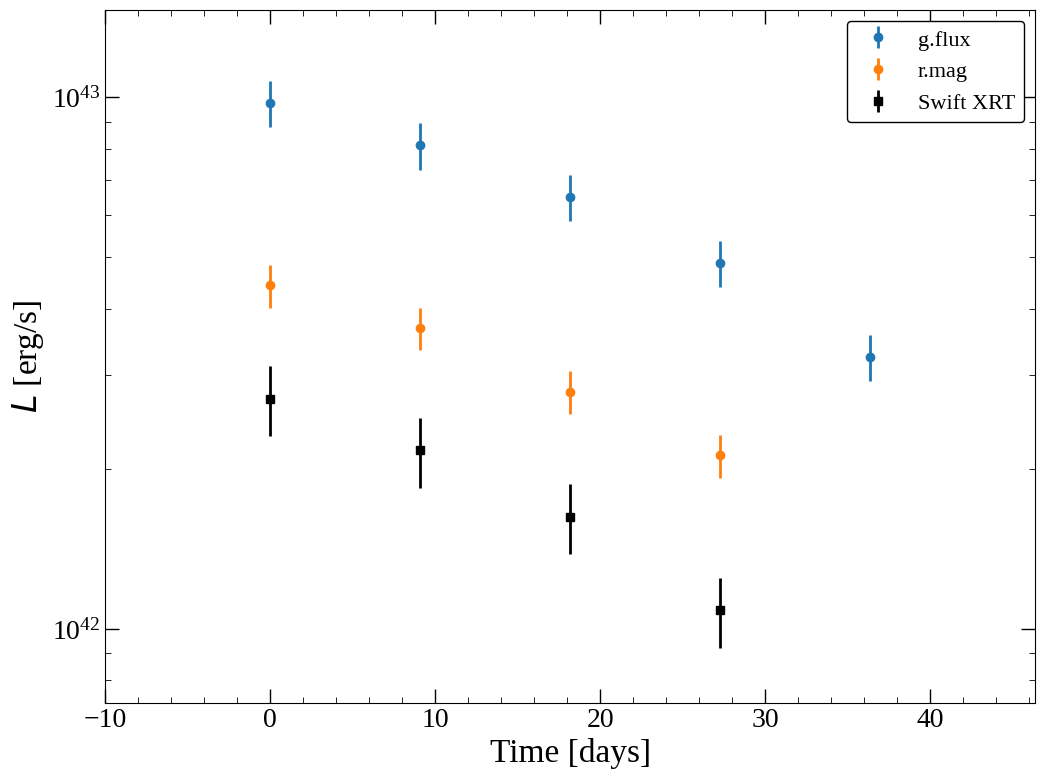

In [7]:
fig = data_mixed.plot_data()
plt.show()

## Summary

- Pass observer-frame data with `args_*_flux` / `args_*_mag` plus a `redshift`, and
  FitTeD does time dilation, frequency shifting and the distance conversion.
- `d_L` comes from `astropy.cosmology.Planck18`.
- The monochromatic conversion is exact in νL_ν; the band-integrated X-ray one assumes
  a unit K-correction, and warns you.
- Upper limits use a sigma count in place of an uncertainty.
- Formats can be mixed freely in one `Data_Set`, provided band names are distinct.

## Next steps

- **Tutorial 03: Model Setup and Parameters**

## Further reading

- **Paper Section 3**: data handling (arXiv:2408.15048)